# U-RNN oficial com UrbanFlood24 Lite no Google Colab/GPU

Este notebook foi preparado para executar, no **Google Colab com GPU**, uma inferência oficial do U-RNN usando **UrbanFlood24 Lite** e **pesos pré-treinados oficiais** do repositório `holmescao/U-RNN`.

Antes de executar, selecione: `Ambiente de execução` > `Alterar tipo de ambiente de execução` > `GPU`. Depois execute as células em ordem.

A rota principal deste notebook agora é a inferência real com o material oficial:

- clonar o repositório `holmescao/U-RNN`;
- instalar dependências do projeto oficial, sem substituir o PyTorch do Colab;
- baixar pesos pré-treinados `Location1 lite`;
- baixar um evento demonstrativo do UrbanFlood24 Lite;
- executar `test.py` com `configs/lite.yaml`;
- exibir a figura oficial com referência, predição U-RNN e erro absoluto;
- gerar um GIF oficial com a evolução temporal de referência, predição e erro.

A mini U-RNN sintética permanece no notebook como seção complementar didática, útil para explicar a lógica de ConvGRU, nowcasting autoregressivo e métricas.


## Relação com o artigo e com o repositório oficial

O artigo U-RNN propõe um modelo recorrente convolucional em arquitetura U-like para nowcasting espaço-temporal de inundações urbanas. O repositório oficial fornece tutoriais, configurações, pesos pré-treinados e dados em formato compatível com o pipeline do artigo.

Nesta versão Colab, a parte principal segue diretamente o repositório oficial:

- dataset: **UrbanFlood24 Lite**, versão reduzida do UrbanFlood24;
- localização: `location1`;
- grade: `128 x 128`;
- sequência: `36` passos temporais;
- configuração: `configs/lite.yaml`;
- pesos: `20260316_130418_443889`, informados no tutorial oficial de pesos pré-treinados;
- saída: figura com referência MIKE+, predição U-RNN e erro absoluto.

A seção sintética, mantida depois da inferência oficial, não substitui a execução com UrbanFlood24 Lite; ela serve apenas como apoio didático para explicar a arquitetura e o fluxo de nowcasting.


## Preparação para Google Colab

As próximas células preparam o ambiente oficial do U-RNN no Colab. O PyTorch não será reinstalado, porque o Colab já fornece uma versão compatível com CUDA quando o runtime de GPU está habilitado.

O notebook detecta a GPU com `nvidia-smi` e usa `--device 0` no `test.py` oficial quando uma GPU está disponível. Se nenhuma GPU for detectada, o notebook ainda pode tentar rodar em CPU, mas a execução fica mais lenta.


In [1]:
# Esta célula prepara o ambiente Colab para a inferência oficial do U-RNN.
# No Colab, selecione GPU em: Ambiente de execução > Alterar tipo de ambiente de execução > GPU.

import os
import sys
import glob
import zipfile
import subprocess
from pathlib import Path

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

gpu_query = subprocess.run(
    ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
    capture_output=True,
    text=True,
)

if gpu_query.returncode == 0:
    OFFICIAL_DEVICE = "0"
    print("GPU detectada:", gpu_query.stdout.strip())
else:
    OFFICIAL_DEVICE = "cpu"
    print("GPU não detectada. A inferência oficial será tentada em CPU, mas pode ficar mais lenta.")

print("Ambiente:", "Google Colab" if IN_COLAB else "local")


GPU detectada: Tesla T4, 15360 MiB
Ambiente: Google Colab


## Clone do repositório oficial e dependências

Esta etapa clona o repositório `holmescao/U-RNN`, entra no diretório `code` e instala as dependências usadas pelo script oficial de inferência.

A instalação evita reinstalar PyTorch, pois o runtime de GPU do Colab já fornece `torch` com CUDA.


In [2]:
# Esta célula clona o repositório oficial, instala dependências auxiliares
# e aplica um patch local para persistir os arrays temporais da inferência.

import os
import re
from pathlib import Path

URN_REPO = Path("/content/U-RNN") if IN_COLAB else Path.cwd() / "external" / "U-RNN"
URN_CODE = URN_REPO / "code"

if not URN_REPO.exists():
    !git clone https://github.com/holmescao/U-RNN {URN_REPO} --quiet
else:
    print("Repositório oficial já existe:", URN_REPO)

%cd {URN_CODE}
!pip install -q pyyaml tqdm openpyxl seaborn celluloid opencv-python-headless

# O test.py oficial gera a figura e as métricas, mas não salva as séries temporais
# de predição/referência. Este patch local não altera o modelo; ele apenas salva
# os arrays .npy para permitir criar um GIF didático da inferência oficial.
test_py_path = URN_CODE / "test.py"
patch_marker = "CODEx_COLAB_SAVE_TEMPORAL_ARRAYS"
test_py_text = test_py_path.read_text(encoding="utf-8")

if patch_marker not in test_py_text:
    save_arrays_block = """
        # CODEx_COLAB_SAVE_TEMPORAL_ARRAYS
        event_name_for_arrays = os.path.basename(event_dir[0])
        save_epoch_sample_for_arrays = os.path.join(save_epoch, event_name_for_arrays)
        os.makedirs(save_epoch_sample_for_arrays, exist_ok=True)
        np.save(
            os.path.join(save_epoch_sample_for_arrays, "u_rnn_prediction_mm.npy"),
            output_mm.astype(np.float32),
        )
        np.save(
            os.path.join(save_epoch_sample_for_arrays, "reference_mike_plus_mm.npy"),
            gt_mm.astype(np.float32),
        )
"""

    patterns = [
        r"(?P<line>^[ \t]*gt_mm\s*=\s*target_vars\[0\]\.numpy\(\).*?$)",
        r"(?P<line>^[ \t]*gt_mm\s*=\s*target_vars\[0\]\.numpy\(\))",
    ]

    patched_text = None
    for pattern in patterns:
        patched_text, count = re.subn(
            pattern,
            lambda match: match.group("line") + save_arrays_block,
            test_py_text,
            count=1,
            flags=re.MULTILINE,
        )
        if count == 1:
            break

    if patched_text is None or patched_text == test_py_text:
        raise RuntimeError("Não foi possível localizar a linha gt_mm no test.py para salvar os arrays temporais.")

    test_py_path.write_text(patched_text, encoding="utf-8")
    print("Patch aplicado em test.py para salvar arrays temporais .npy.")
else:
    print("Patch de arrays temporais já estava aplicado em test.py.")

import torch
print("Diretório de trabalho:", os.getcwd())
print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU PyTorch:", torch.cuda.get_device_name(0))


/content/U-RNN/code
Patch aplicado em test.py para salvar arrays temporais .npy.
Diretório de trabalho: /content/U-RNN/code
PyTorch: 2.11.0+cu128
CUDA disponível: True
GPU PyTorch: Tesla T4


## Download dos pesos pré-treinados e do evento UrbanFlood24 Lite

Esta etapa baixa dois arquivos oficiais usados pelo quickstart:

- `loc1_lite_weights.zip`: pesos pré-treinados para `UrbanFlood24 Lite location1`;
- `loc1_lite_demo_r100y.zip`: evento demonstrativo `r100y_p0.5_d3h`.

O evento demo contém a referência hidrodinâmica (`flood.npy`), a chuva (`rainfall.npy`) e as camadas geoespaciais necessárias para a inferência.


In [3]:
# Esta célula baixa pesos oficiais e um evento demonstrativo do UrbanFlood24 Lite.

import os
import glob
import zipfile
from pathlib import Path

WEIGHTS_HF_URL = "https://huggingface.co/holmescao/U-RNN/resolve/main/checkpoints/loc1_lite_weights.zip"
DEMO_DATA_HF_URL = "https://huggingface.co/holmescao/U-RNN/resolve/main/demo_data/loc1_lite_demo_r100y.zip"

TIMESTAMP = "20260316_130418_443889"
LOCATION = "location1"
DEMO_EVENT = "r100y_p0.5_d3h"
DATA_ROOT = "../data/urbanflood24_lite"

checkpoint_glob = f"../exp/{TIMESTAMP}/save_model/*.pth.tar"
existing_checkpoints = glob.glob(checkpoint_glob)

if existing_checkpoints:
    print("Pesos já encontrados:", existing_checkpoints[0])
else:
    print("Baixando pesos pré-treinados Location1 Lite (~20 MB)...")
    !wget -q --show-progress -O /tmp/loc1_lite_weights.zip {WEIGHTS_HF_URL}
    with zipfile.ZipFile("/tmp/loc1_lite_weights.zip", "r") as zip_file:
        zip_file.extractall("..")
    existing_checkpoints = glob.glob(checkpoint_glob)

if not existing_checkpoints:
    raise FileNotFoundError("Checkpoint oficial não encontrado após extração dos pesos.")

checkpoint_path = existing_checkpoints[0]
print("Checkpoint oficial:", checkpoint_path)

demo_event_path = Path(DATA_ROOT) / "test" / "flood" / LOCATION / DEMO_EVENT
if demo_event_path.exists():
    print("Evento demo já encontrado:", demo_event_path)
else:
    print("Baixando evento demo UrbanFlood24 Lite (~1.5 MB)...")
    !wget -q --show-progress -O /tmp/loc1_lite_demo_r100y.zip {DEMO_DATA_HF_URL}
    with zipfile.ZipFile("/tmp/loc1_lite_demo_r100y.zip", "r") as zip_file:
        zip_file.extractall("../data")

assert (demo_event_path / "flood.npy").is_file(), "flood.npy não encontrado."
assert (demo_event_path / "rainfall.npy").is_file(), "rainfall.npy não encontrado."

import numpy as np
flood_shape = np.load(demo_event_path / "flood.npy").shape
rain_shape = np.load(demo_event_path / "rainfall.npy").shape
print("Evento demo:", demo_event_path)
print("flood.npy shape:", flood_shape)
print("rainfall.npy shape:", rain_shape)


Baixando pesos pré-treinados Location1 Lite (~20 MB)...
/tmp/loc1_lite_weig 100%[===================>]  19.39M  16.6MB/s    in 1.2s    
Checkpoint oficial: ../exp/20260316_130418_443889/save_model/checkpoint_143_0.065581453.pth.tar
Baixando evento demo UrbanFlood24 Lite (~1.5 MB)...
/tmp/loc1_lite_demo 100%[===================>]   1.43M  4.25MB/s    in 0.3s    
Evento demo: ../data/urbanflood24_lite/test/flood/location1/r100y_p0.5_d3h
flood.npy shape: (36, 128, 128)
rainfall.npy shape: (18,)


## Inferência oficial com `test.py`

Agora executamos o script oficial `test.py` com a configuração `configs/lite.yaml`. A saída esperada é uma figura de comparação com três linhas: referência MIKE+, predição U-RNN e erro absoluto.


In [4]:
# Esta célula executa a inferência oficial do U-RNN com UrbanFlood24 Lite.

from pathlib import Path

test_list_file = Path("/tmp/loc1_lite_demo.txt")
test_list_file.write_text(DEMO_EVENT + "\n")

print("Executando inferência oficial no dispositivo:", OFFICIAL_DEVICE)
!python test.py \
    --exp_config configs/lite.yaml \
    --timestamp {TIMESTAMP} \
    --data_root {DATA_ROOT} \
    --location {LOCATION} \
    --test_list_file {test_list_file} \
    --device {OFFICIAL_DEVICE}


Executando inferência oficial no dispositivo: 0
train_config: /content/U-RNN/code/configs/defaults/training.yaml
data_config: /content/U-RNN/code/configs/defaults/data.yaml
net_config: None
exp_config: configs/lite.yaml
local_rank: -1
exp_name: U-RNN
exp_root: ../exp
exp_dir: ../exp/20260316_130418_443889
timestamp: 20260316_130418_443889
data_root: ../data/urbanflood24_lite
input_height: 128
input_width: 128
historical_nums: 3
duration: 36
location: location1
flood_max: 5000
rain_max: 60.0
cumsum_rain_max: 250.0
flood_thres: 150.0
viz_time_points: [0, 11, 23, 35]
epochs: 1000
batch_size: 1
random_seed: 42
num_workers: 4
seq_num: 9
window_size: 36
train_event: True
all_seq_train: False
full_window_size: False
wind_random: True
prewarming: False
lr: 0.01
lr_min: 0.0001
schedule_name: WarmUpCosineAnneal
warm_up_iter: 10
patience: 10
factor: 0.9
grad_clip: 1.0
loss_name: FocalBCE_and_WMSE
reduction: mean
cls_thred: 0.5
clstm: False
use_checkpoint: True
blocks: 3
device: 0
amp: False
resum

## Visualização da inferência oficial

A figura gerada pelo repositório oficial mostra, para diferentes instantes do evento, a referência hidrodinâmica, a predição do U-RNN e o erro absoluto.

Essa é a evidência mais forte do notebook Colab, pois utiliza o pipeline, os pesos e o dado demonstrativo oficial do U-RNN.


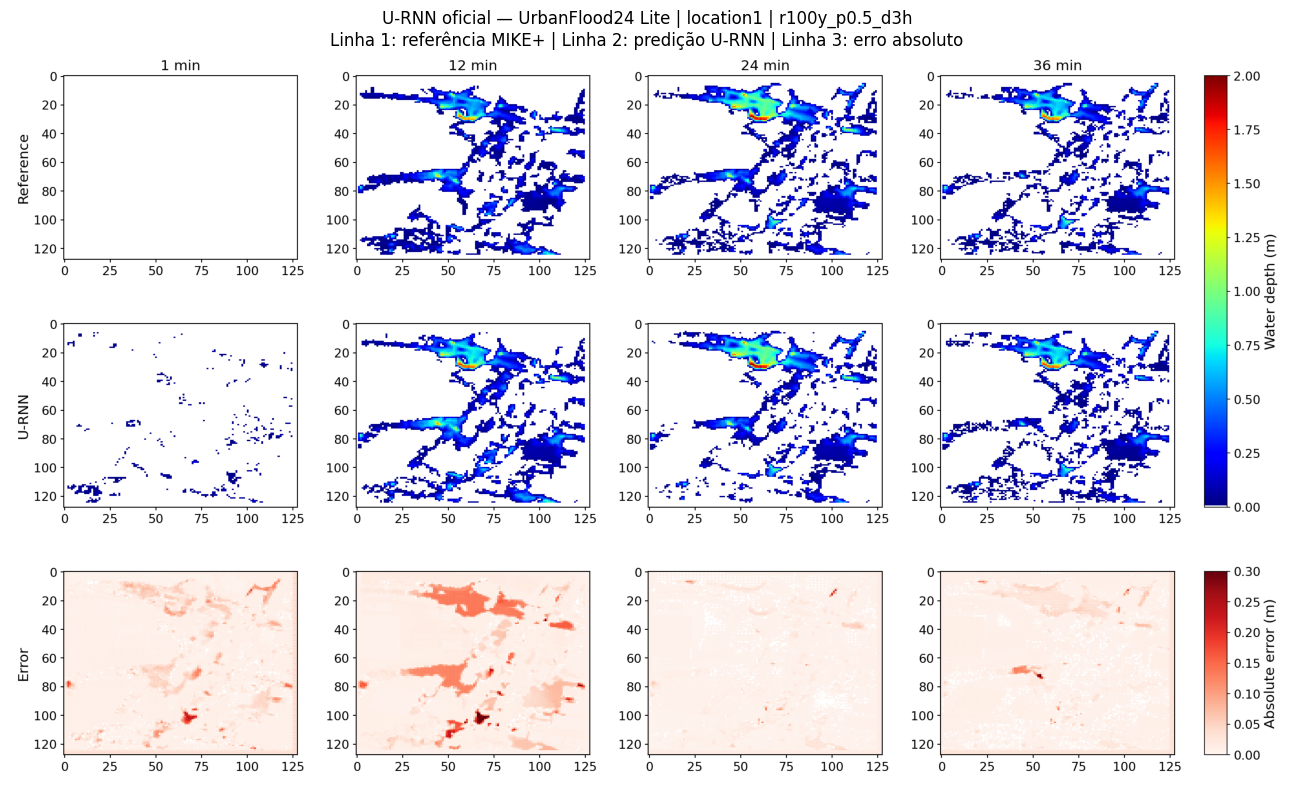

Figura oficial: ../exp/20260316_130418_443889/figs/epoch@100/r100y_p0.5_d3h/water_depth_spatial_temporal.png
Cópia para entrega: /content/outputs_urnn_official/u_rnn_official_urbanflood24_lite.png
Métricas oficiais copiadas: ['metrics_epoch100.xlsx']


In [5]:
# Esta célula localiza e exibe a figura oficial gerada pelo test.py.

import glob
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

figure_pattern = f"../exp/{TIMESTAMP}/figs/**/{DEMO_EVENT}/water_depth_spatial_temporal.png"
figures = sorted(glob.glob(figure_pattern, recursive=True))

if not figures:
    raise FileNotFoundError("Figura oficial não encontrada. Verifique a saída do test.py acima.")

official_figure = figures[-1]
image = mpimg.imread(official_figure)

fig, ax = plt.subplots(figsize=(16, 8))
ax.imshow(image)
ax.axis("off")
ax.set_title(
    f"U-RNN oficial — UrbanFlood24 Lite | {LOCATION} | {DEMO_EVENT}\n"
    "Linha 1: referência MIKE+ | Linha 2: predição U-RNN | Linha 3: erro absoluto",
    fontsize=12,
)
plt.tight_layout()
plt.show()

outputs_dir = Path("/content/outputs_urnn_official") if IN_COLAB else Path.cwd() / "outputs_urnn_official"
outputs_dir.mkdir(parents=True, exist_ok=True)
copied_figure = outputs_dir / "u_rnn_official_urbanflood24_lite.png"
shutil.copy2(official_figure, copied_figure)

metrics_files = sorted(glob.glob(f"../exp/{TIMESTAMP}/metrics/*.xlsx"))
for metrics_file in metrics_files:
    shutil.copy2(metrics_file, outputs_dir / Path(metrics_file).name)

print("Figura oficial:", official_figure)
print("Cópia para entrega:", copied_figure)
if metrics_files:
    print("Métricas oficiais copiadas:", [Path(m).name for m in metrics_files])


## GIF da inferência oficial

A figura oficial é estática e resume alguns instantes temporais. Para evidenciar o comportamento de nowcasting, esta seção usa os arrays temporais salvos pelo patch local do `test.py` e cria um GIF com três painéis por passo: referência MIKE+, predição U-RNN e erro absoluto.


Arrays usados:
Predição: ../exp/20260316_130418_443889/figs/epoch@100/r100y_p0.5_d3h/u_rnn_prediction_mm.npy (36, 128, 128)
Referência: ../exp/20260316_130418_443889/figs/epoch@100/r100y_p0.5_d3h/reference_mike_plus_mm.npy (36, 128, 128)
GIF oficial salvo: /content/outputs_urnn_official/u_rnn_official_urbanflood24_lite.gif


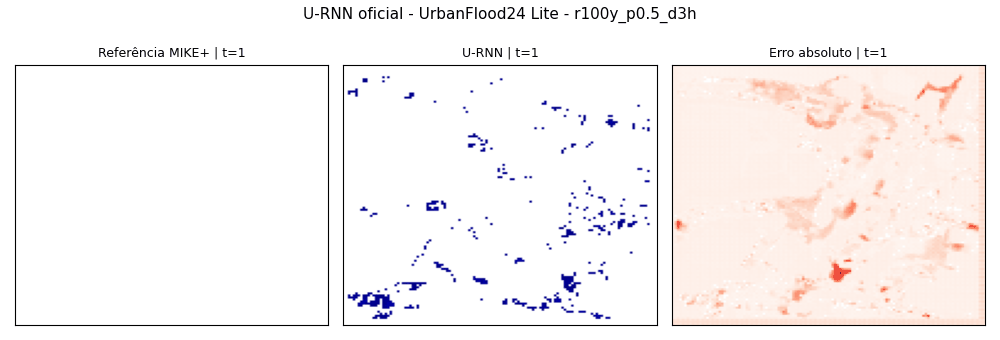

In [6]:
# Esta célula cria um GIF da inferência oficial com UrbanFlood24 Lite.
# Ela usa os arrays .npy salvos pelo patch aplicado ao test.py.

import glob
import shutil
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
from PIL import Image as PILImage
from pathlib import Path

prediction_pattern = f"../exp/{TIMESTAMP}/figs/**/{DEMO_EVENT}/u_rnn_prediction_mm.npy"
reference_pattern = f"../exp/{TIMESTAMP}/figs/**/{DEMO_EVENT}/reference_mike_plus_mm.npy"
prediction_files = sorted(glob.glob(prediction_pattern, recursive=True))
reference_files = sorted(glob.glob(reference_pattern, recursive=True))

if not prediction_files or not reference_files:
    raise FileNotFoundError(
        "Arrays temporais oficiais não encontrados. Execute novamente a célula de clone/patch "
        "e depois a inferência oficial com test.py."
    )

official_prediction_mm = np.load(prediction_files[-1]).astype(np.float32)
official_reference_mm = np.load(reference_files[-1]).astype(np.float32)

if official_prediction_mm.shape != official_reference_mm.shape:
    raise ValueError(
        "Predição e referência têm formatos diferentes: "
        f"{official_prediction_mm.shape} vs {official_reference_mm.shape}"
    )

official_prediction_m = official_prediction_mm / 1000.0
official_reference_m = official_reference_mm / 1000.0
official_error_m = np.abs(official_prediction_m - official_reference_m)

depth_cmap_arr = plt.cm.jet(np.linspace(0, 1, 256))
depth_cmap_arr[0] = (1, 1, 1, 1)
depth_cmap = ListedColormap(depth_cmap_arr)
depth_cmap.set_bad("white")

error_cmap_arr = plt.cm.Reds(np.linspace(0, 1, 256))
error_cmap_arr[0] = (1, 1, 1, 1)
error_cmap = ListedColormap(error_cmap_arr)
error_cmap.set_bad("white")

# Mantém a escala visual usada pelo script oficial: profundidade em 0-2 m e erro em 0-0,3 m.
depth_norm = Normalize(vmin=0.0, vmax=2.0)
error_norm = Normalize(vmin=0.0, vmax=0.3)

def mask_zero_water(array):
    """Oculta células secas para manter fundo branco, como no gráfico oficial."""
    masked = array.copy()
    masked[masked <= 0.0] = np.nan
    return masked

frames = []
frame_count = official_prediction_m.shape[0]
for step in range(frame_count):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), dpi=100)
    panels = [
        (mask_zero_water(official_reference_m[step]), "Referência MIKE+", depth_cmap, depth_norm),
        (mask_zero_water(official_prediction_m[step]), "U-RNN", depth_cmap, depth_norm),
        (mask_zero_water(official_error_m[step]), "Erro absoluto", error_cmap, error_norm),
    ]

    for ax, (data, title, cmap, norm) in zip(axes, panels):
        ax.imshow(data, cmap=cmap, norm=norm, aspect="auto")
        ax.set_title(f"{title} | t={step + 1}", fontsize=9)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(f"U-RNN oficial - UrbanFlood24 Lite - {DEMO_EVENT}", fontsize=11)
    fig.tight_layout()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba())[:, :, :3].copy()
    frames.append(PILImage.fromarray(frame))
    plt.close(fig)

outputs_dir = Path("/content/outputs_urnn_official") if IN_COLAB else Path.cwd() / "outputs_urnn_official"
outputs_dir.mkdir(parents=True, exist_ok=True)
official_gif_path = outputs_dir / "u_rnn_official_urbanflood24_lite.gif"

frames[0].save(
    official_gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=180,
    loop=0,
    optimize=True,
)

print("Arrays usados:")
print("Predição:", prediction_files[-1], official_prediction_mm.shape)
print("Referência:", reference_files[-1], official_reference_mm.shape)
print("GIF oficial salvo:", official_gif_path)

try:
    from IPython.display import Image as IPythonImage, display
    display(IPythonImage(filename=str(official_gif_path)))
except Exception as exc:
    print("GIF criado, mas não foi possível exibir inline:", exc)


In [7]:
# Esta célula verifica se as dependências principais estão instaladas.
# A execução usa GPU automaticamente quando torch.cuda.is_available() retornar True.
# No Colab, evite instalar o requirements.txt local, pois ele usa PyTorch CPU-only.

import importlib.util
import os
import platform
import sys
from pathlib import Path

required_modules = ["numpy", "matplotlib", "torch", "PIL"]
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]

if missing_modules:
    raise ImportError(
        "Dependências ausentes: " + ", ".join(missing_modules) +
        ". No Colab com GPU, o PyTorch costuma vir pré-instalado. "
        "Se estiver em ambiente local, instale as dependências apropriadas para sua máquina."
    )

import csv
import json
import math
import random
import time

Path(".matplotlib-cache").mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(Path(".matplotlib-cache").resolve()))

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
Sistema: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
CUDA disponível: True
GPU: Tesla T4


In [8]:
# Esta célula define parâmetros globais.
# Em GPU, usamos uma configuração moderadamente maior. Em CPU, usamos fallback leve.

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figuras"
GIF_DIR = OUTPUT_DIR / "animacoes"
METRIC_DIR = OUTPUT_DIR / "metricas"
LOG_DIR = OUTPUT_DIR / "logs"

for path in [FIG_DIR, GIF_DIR, METRIC_DIR, LOG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if DEVICE.type == "cuda":
    RUN_PROFILE = "colab_gpu"
    GRID_H = 64
    GRID_W = 64
    TIME_STEPS = 36
    TRAIN_EVENTS = 24
    TEST_EVENTS = 4
    EPOCHS = 40
    LEARNING_RATE = 0.006
    torch.backends.cudnn.benchmark = True
else:
    RUN_PROFILE = "cpu_fallback"
    GRID_H = 32
    GRID_W = 32
    TIME_STEPS = 24
    TRAIN_EVENTS = 10
    TEST_EVENTS = 3
    EPOCHS = 15
    LEARNING_RATE = 0.01

WET_THRESHOLD_M = 0.03
MAX_DEPTH_M = 0.60
RAIN_MAX_MM = 45.0
CUM_RAIN_MAX_MM = 360.0 if DEVICE.type == "cuda" else 240.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Diretório do projeto:", PROJECT_ROOT)
print("Diretório de saídas:", OUTPUT_DIR)
print("Perfil de execução:", RUN_PROFILE)
print("Dispositivo usado:", DEVICE)
print(f"Grade: {GRID_H} x {GRID_W} | Passos temporais: {TIME_STEPS} | Eventos treino: {TRAIN_EVENTS} | Épocas: {EPOCHS}")


Diretório do projeto: /content/U-RNN/code
Diretório de saídas: /content/U-RNN/code/outputs
Perfil de execução: colab_gpu
Dispositivo usado: cuda
Grade: 64 x 64 | Passos temporais: 36 | Eventos treino: 24 | Épocas: 40


## Seção complementar: geração de dados sintéticos

A partir daqui, o notebook volta para a implementação didática própria. Esta seção é complementar à inferência oficial acima. Ela ajuda a explicar, em escala menor, como um pipeline de nowcasting pode gerar entradas, treinar uma rede recorrente convolucional e avaliar mapas temporais de inundação.

O artigo utiliza dados hidrodinâmicos simulados e camadas espaciais reais, como DSM, impermeabilidade e drenagem. Nesta seção didática, essas entradas são representadas por dados sintéticos para permitir experimentação rápida.

Cada evento sintético contém:

- uma série temporal de chuva;
- uma chuva acumulada derivada;
- uma grade de elevação normalizada;
- uma grade de impermeabilidade;
- uma grade de drenagem;
- uma sequência de profundidade de inundação usada como referência didática.

A referência de inundação é gerada por uma regra simplificada de acumulação, drenagem e difusão espacial. Ela serve para testar o pipeline de aprendizado de máquina, mas não deve ser interpretada como uma simulação hidrodinâmica real.


In [10]:
# Esta celula define funcoes para gerar dados sinteticos.
# A referencia de inundacao e produzida por uma regra simplificada de acumulacao,
# drenagem e difusao espacial. Ela nao e um solver hidrodinamico real.

def minmax_scale(array, eps=1e-8):
    """Normaliza um array para o intervalo [0, 1]."""
    array = np.asarray(array, dtype=np.float32)
    return (array - array.min()) / (array.max() - array.min() + eps)


def smooth2d(array, rounds=2):
    """Aplica uma suavizacao simples por vizinhanca usando deslocamentos de grade."""
    smoothed = array.astype(np.float32).copy()
    for _ in range(rounds):
        smoothed = (
            smoothed
            + np.roll(smoothed, 1, axis=0)
            + np.roll(smoothed, -1, axis=0)
            + np.roll(smoothed, 1, axis=1)
            + np.roll(smoothed, -1, axis=1)
        ) / 5.0
    return smoothed


def make_spatial_fields(height, width, rng):
    """Cria elevacao, impermeabilidade e drenagem sinteticas."""
    y, x = np.mgrid[0:height, 0:width]
    x_norm = x / max(width - 1, 1)
    y_norm = y / max(height - 1, 1)

    slope = 0.55 * x_norm + 0.25 * y_norm
    depression_1 = -0.35 * np.exp(-((x_norm - 0.35) ** 2 + (y_norm - 0.70) ** 2) / 0.020)
    depression_2 = -0.22 * np.exp(-((x_norm - 0.72) ** 2 + (y_norm - 0.38) ** 2) / 0.030)
    roughness = smooth2d(rng.normal(0.0, 0.035, size=(height, width)), rounds=4)
    elevation = minmax_scale(slope + depression_1 + depression_2 + roughness)

    road_horizontal = np.exp(-((y_norm - 0.55) ** 2) / 0.0025)
    road_vertical = np.exp(-((x_norm - 0.48) ** 2) / 0.0020)
    built_blocks = smooth2d((rng.random((height, width)) > 0.62).astype(np.float32), rounds=2)
    impervious = np.clip(0.25 + 0.45 * built_blocks + 0.35 * road_horizontal + 0.35 * road_vertical, 0.0, 1.0)

    drainage = np.zeros((height, width), dtype=np.float32)
    candidate_mask = (road_horizontal + road_vertical > 0.55) & (elevation < 0.72)
    drainage[candidate_mask & (rng.random((height, width)) > 0.86)] = 1.0
    drainage = smooth2d(drainage, rounds=1)
    drainage = np.clip(drainage, 0.0, 1.0)

    return {
        "elevation": elevation.astype(np.float32),
        "impervious": impervious.astype(np.float32),
        "drainage": drainage.astype(np.float32),
    }


def make_rain_event(time_steps, rng):
    """Gera uma chuva temporal com pico principal e pico secundario."""
    t = np.arange(time_steps, dtype=np.float32)
    peak = rng.uniform(0.35, 0.70) * time_steps
    width = rng.uniform(2.8, 5.2)
    intensity = rng.uniform(22.0, 42.0)
    secondary_peak = rng.uniform(0.10, 0.90) * time_steps
    secondary_intensity = rng.uniform(4.0, 11.0)

    rain = intensity * np.exp(-0.5 * ((t - peak) / width) ** 2)
    rain += secondary_intensity * np.exp(-0.5 * ((t - secondary_peak) / 2.4) ** 2)
    rain += rng.uniform(0.0, 1.2, size=time_steps)
    return rain.astype(np.float32)


def simulate_reference_flood(rainfall_mm, spatial_fields):
    """Simula uma referencia sintetica de profundidade de inundacao em metros."""
    elevation = spatial_fields["elevation"]
    impervious = spatial_fields["impervious"]
    drainage = spatial_fields["drainage"]
    low_area = 1.0 - elevation

    height, width = elevation.shape
    water = np.zeros((height, width), dtype=np.float32)
    sequence = []

    for rain_mm in rainfall_mm:
        rain_m = rain_mm / 1000.0
        runoff = rain_m * (0.22 + 0.88 * impervious) * (0.55 + 0.75 * low_area)

        neighbor_mean = (
            np.roll(water, 1, axis=0)
            + np.roll(water, -1, axis=0)
            + np.roll(water, 1, axis=1)
            + np.roll(water, -1, axis=1)
        ) / 4.0

        diffusion = 0.18 * (neighbor_mean - water)
        retention = 0.82 + 0.16 * low_area
        drain_loss = water * (0.025 + 0.32 * drainage)

        water = water * retention + runoff + diffusion - drain_loss
        water = np.clip(water, 0.0, MAX_DEPTH_M)
        sequence.append(water.astype(np.float32).copy())

    return np.stack(sequence, axis=0)


def build_synthetic_dataset(train_events, test_events, height, width, time_steps, seed):
    """Cria eventos de treino e teste com a mesma geografia sintetica."""
    rng = np.random.default_rng(seed)
    spatial_fields = make_spatial_fields(height, width, rng)
    all_events = []

    for event_id in range(train_events + test_events):
        rainfall = make_rain_event(time_steps, rng)
        flood = simulate_reference_flood(rainfall, spatial_fields)
        all_events.append({
            "event_id": f"event_{event_id:02d}",
            "rainfall": rainfall,
            "flood": flood,
        })

    return spatial_fields, all_events[:train_events], all_events[train_events:]

In [11]:
# Esta celula cria o dataset sintetico e mostra os formatos.
# Os formatos seguem a ideia do repositorio oficial: flood em (T, H, W) e rainfall em (T,).

spatial_fields, train_data, test_data = build_synthetic_dataset(
    train_events=TRAIN_EVENTS,
    test_events=TEST_EVENTS,
    height=GRID_H,
    width=GRID_W,
    time_steps=TIME_STEPS,
    seed=SEED,
)

example_event = train_data[0]

print("Eventos de treino:", len(train_data))
print("Eventos de teste:", len(test_data))
print("rainfall shape:", example_event["rainfall"].shape)
print("flood shape:", example_event["flood"].shape)
print("elevation shape:", spatial_fields["elevation"].shape)

Eventos de treino: 24
Eventos de teste: 4
rainfall shape: (36,)
flood shape: (36, 64, 64)
elevation shape: (64, 64)


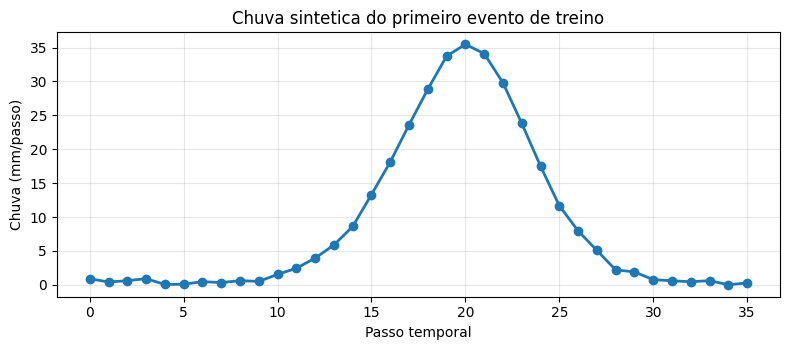

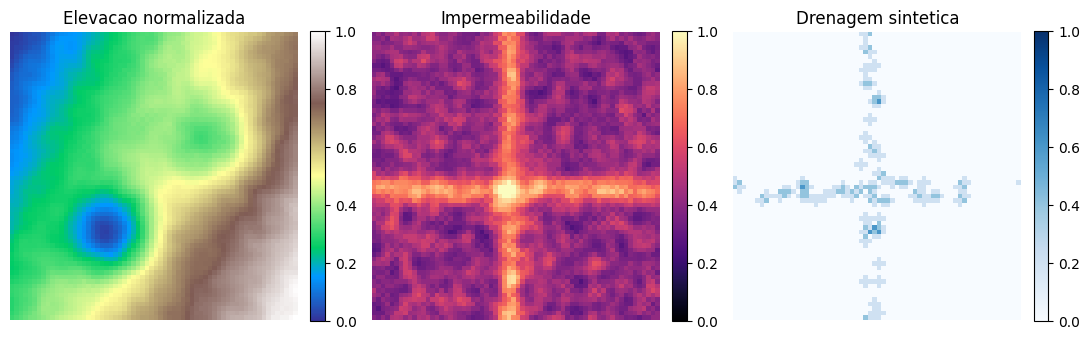

Figura salva: /content/U-RNN/code/outputs/figuras/entrada_chuva.png
Figura salva: /content/U-RNN/code/outputs/figuras/variaveis_espaciais.png


In [12]:
# Esta celula visualiza as entradas principais usadas pelo modelo.
# Ela salva duas evidencias: a chuva temporal e as camadas espaciais sinteticas.

rain_path = FIG_DIR / "entrada_chuva.png"
spatial_path = FIG_DIR / "variaveis_espaciais.png"

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(example_event["rainfall"], marker="o", linewidth=2)
ax.set_title("Chuva sintetica do primeiro evento de treino")
ax.set_xlabel("Passo temporal")
ax.set_ylabel("Chuva (mm/passo)")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(rain_path, dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
layers = [
    ("Elevacao normalizada", spatial_fields["elevation"], "terrain"),
    ("Impermeabilidade", spatial_fields["impervious"], "magma"),
    ("Drenagem sintetica", spatial_fields["drainage"], "Blues"),
]

for axis, (title, layer, cmap) in zip(axes, layers):
    image = axis.imshow(layer, cmap=cmap, vmin=0, vmax=1)
    axis.set_title(title)
    axis.axis("off")
    fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(spatial_path, dpi=150)
plt.show()

print("Figura salva:", rain_path)
print("Figura salva:", spatial_path)

## Mini U-RNN em PyTorch

A arquitetura abaixo é reduzida, mas preserva a lógica central usada pelo U-RNN: processar mapas espaciais ao longo do tempo e manter um estado recorrente que representa a evolução da inundação.

Componentes principais desta mini U-RNN:

- entrada com chuva atual, chuva acumulada, elevação, impermeabilidade, drenagem e profundidade anterior;
- encoder convolucional em resolução original;
- camada profunda em meia resolução;
- células ConvGRU para manter estado temporal;
- upsampling e skip connection no estilo U-like;
- cabeça de profundidade e cabeça de classificação molhado/seco.

Durante o treino, usamos **teacher forcing**: a profundidade anterior vem da referência sintética. Durante a inferência, o modelo usa sua própria predição anterior como entrada do próximo passo temporal. Esse comportamento simula o nowcasting autoregressivo, no qual a previsão evolui passo a passo no tempo.

In [13]:
# Esta celula implementa a celula ConvGRU e a mini arquitetura U-like.
# Ela e propositalmente pequena para rodar em CPU e servir como demonstracao didatica.

class ConvGRUCell(nn.Module):
    """Celula ConvGRU simples com gates calculados por convolucoes 2D."""

    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(input_channels + hidden_channels, 2 * hidden_channels, kernel_size, padding=padding)
        self.candidate = nn.Conv2d(input_channels + hidden_channels, hidden_channels, kernel_size, padding=padding)

    def forward(self, x, h_prev=None):
        if h_prev is None:
            h_prev = torch.zeros(
                x.shape[0], self.hidden_channels, x.shape[2], x.shape[3],
                device=x.device, dtype=x.dtype,
            )

        gate_input = torch.cat([x, h_prev], dim=1)
        reset_gate, update_gate = torch.chunk(torch.sigmoid(self.gates(gate_input)), chunks=2, dim=1)
        candidate_input = torch.cat([x, reset_gate * h_prev], dim=1)
        candidate_state = torch.tanh(self.candidate(candidate_input))
        h_new = (1.0 - update_gate) * h_prev + update_gate * candidate_state
        return h_new


class MiniURNN(nn.Module):
    """Mini rede U-like recorrente inspirada no U-RNN."""

    def __init__(self, input_channels=6, hidden_full=8, hidden_deep=12, max_depth=0.60):
        super().__init__()
        self.max_depth = max_depth
        self.input_projection = nn.Conv2d(input_channels, hidden_full, kernel_size=3, padding=1)
        self.full_gru = ConvGRUCell(hidden_full, hidden_full)
        self.downsample = nn.Conv2d(hidden_full, hidden_deep, kernel_size=3, stride=2, padding=1)
        self.deep_gru = ConvGRUCell(hidden_deep, hidden_deep)
        self.upsample = nn.ConvTranspose2d(hidden_deep, hidden_full, kernel_size=2, stride=2)
        self.fuse = nn.Conv2d(hidden_full * 2, hidden_full, kernel_size=3, padding=1)
        self.depth_head = nn.Conv2d(hidden_full, 1, kernel_size=1)
        self.wet_head = nn.Conv2d(hidden_full, 1, kernel_size=1)

    def forward_step(self, x, state):
        h_full, h_deep = state

        encoded = F.relu(self.input_projection(x))
        h_full = self.full_gru(encoded, h_full)

        deep_input = F.relu(self.downsample(h_full))
        h_deep = self.deep_gru(deep_input, h_deep)

        decoded = F.relu(self.upsample(h_deep))
        decoded = decoded[:, :, :h_full.shape[2], :h_full.shape[3]]
        fused = F.relu(self.fuse(torch.cat([decoded, h_full], dim=1)))

        depth = torch.sigmoid(self.depth_head(fused)) * self.max_depth
        wet_logits = self.wet_head(fused)
        return depth, wet_logits, (h_full, h_deep)


def make_static_tensor(spatial_fields, device):
    """Converte as camadas espaciais para tensor PyTorch com shape (1, 3, H, W)."""
    static = np.stack([
        spatial_fields["elevation"],
        spatial_fields["impervious"],
        spatial_fields["drainage"],
    ], axis=0)
    return torch.tensor(static, dtype=torch.float32, device=device).unsqueeze(0)


def run_sequence(model, static_tensor, rainfall_mm, target_sequence=None, teacher_forcing=False):
    """Executa a rede passo a passo, preservando o estado recorrente."""
    rainfall = torch.tensor(rainfall_mm, dtype=torch.float32, device=static_tensor.device)
    cumulative = torch.cumsum(rainfall, dim=0)

    batch, _, height, width = static_tensor.shape
    previous_depth = torch.zeros(batch, 1, height, width, device=static_tensor.device)
    state = (None, None)

    predictions = []
    wet_logits_list = []

    for step in range(rainfall.shape[0]):
        rain_grid = torch.full((batch, 1, height, width), rainfall[step] / RAIN_MAX_MM, device=static_tensor.device)
        cumsum_grid = torch.full((batch, 1, height, width), cumulative[step] / CUM_RAIN_MAX_MM, device=static_tensor.device)
        model_input = torch.cat([rain_grid, cumsum_grid, static_tensor, previous_depth / MAX_DEPTH_M], dim=1)

        predicted_depth, wet_logits, state = model.forward_step(model_input, state)
        predictions.append(predicted_depth)
        wet_logits_list.append(wet_logits)

        if teacher_forcing and target_sequence is not None:
            previous_depth = target_sequence[:, step:step + 1]
        else:
            previous_depth = predicted_depth.detach()

    return torch.cat(predictions, dim=1), torch.cat(wet_logits_list, dim=1)


static_tensor = make_static_tensor(spatial_fields, DEVICE)
model = MiniURNN(input_channels=6, hidden_full=8, hidden_deep=12, max_depth=MAX_DEPTH_M).to(DEVICE)
total_params = sum(parameter.numel() for parameter in model.parameters())

print(model)
print(f"Parametros treinaveis: {total_params:,}")

MiniURNN(
  (input_projection): Conv2d(6, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (full_gru): ConvGRUCell(
    (gates): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (candidate): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (downsample): Conv2d(8, 12, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (deep_gru): ConvGRUCell(
    (gates): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (candidate): Conv2d(24, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (upsample): ConvTranspose2d(12, 8, kernel_size=(2, 2), stride=(2, 2))
  (fuse): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (depth_head): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
  (wet_head): Conv2d(8, 1, kernel_size=(1, 1), stride=(1, 1))
)
Parametros treinaveis: 14,178


## Treinamento em GPU com fallback para CPU

Nesta etapa, a mini U-RNN aprende a aproximar a sequência sintética de inundação. Quando uma GPU está disponível, o notebook usa uma configuração um pouco maior; quando não há GPU, mantém uma configuração leve para CPU.

A função de perda combina dois objetivos:

- **erro de profundidade**: compara a profundidade prevista com a referência sintética;
- **erro de área molhada/seca**: ajuda o modelo a distinguir células inundadas e não inundadas.

Essa escolha segue a ideia do artigo de separar regressão de profundidade e classificação de inundação, ainda que em uma arquitetura muito menor.


In [14]:
# Esta celula treina a mini U-RNN por poucas epocas.
# A perda combina regressao de profundidade com classificacao de celula molhada/seca,
# refletindo a ideia das cabecas desacopladas descritas no artigo.

def event_target_tensor(event, device):
    """Converte flood.npy sintetico, shape (T, H, W), para tensor (1, T, H, W)."""
    return torch.tensor(event["flood"], dtype=torch.float32, device=device).unsqueeze(0)


optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
history = []
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    random.shuffle(train_data)
    train_losses = []

    for event in train_data:
        target = event_target_tensor(event, DEVICE)
        wet_target = (target > WET_THRESHOLD_M).float()

        optimizer.zero_grad()
        predicted, wet_logits = run_sequence(
            model,
            static_tensor,
            event["rainfall"],
            target_sequence=target,
            teacher_forcing=True,
        )

        depth_loss = F.mse_loss(predicted, target)
        wet_loss = F.binary_cross_entropy_with_logits(wet_logits, wet_target)
        loss = depth_loss + 0.02 * wet_loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(float(loss.detach().cpu()))

    model.eval()
    val_losses = []
    with torch.no_grad():
        for event in test_data:
            target = event_target_tensor(event, DEVICE)
            predicted, wet_logits = run_sequence(model, static_tensor, event["rainfall"], teacher_forcing=False)
            val_losses.append(float(F.mse_loss(predicted, target).detach().cpu()))

    epoch_record = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_mse": float(np.mean(val_losses)),
    }
    history.append(epoch_record)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={epoch_record['train_loss']:.6f} | val_mse={epoch_record['val_mse']:.6f}")

elapsed = time.time() - start_time
print(f"Treinamento concluido em {elapsed:.1f} segundos no dispositivo {DEVICE}.")

Epoch 01/40 | train_loss=0.035806 | val_mse=0.003528
Epoch 02/40 | train_loss=0.017827 | val_mse=0.002246
Epoch 03/40 | train_loss=0.016777 | val_mse=0.002083
Epoch 04/40 | train_loss=0.016442 | val_mse=0.002086
Epoch 05/40 | train_loss=0.016386 | val_mse=0.001962
Epoch 06/40 | train_loss=0.015923 | val_mse=0.001365
Epoch 07/40 | train_loss=0.014581 | val_mse=0.000660
Epoch 08/40 | train_loss=0.011580 | val_mse=0.000694
Epoch 09/40 | train_loss=0.007509 | val_mse=0.000904
Epoch 10/40 | train_loss=0.005009 | val_mse=0.000915
Epoch 11/40 | train_loss=0.004089 | val_mse=0.000855
Epoch 12/40 | train_loss=0.003448 | val_mse=0.000903
Epoch 13/40 | train_loss=0.002648 | val_mse=0.000969
Epoch 14/40 | train_loss=0.002205 | val_mse=0.000909
Epoch 15/40 | train_loss=0.002603 | val_mse=0.000958
Epoch 16/40 | train_loss=0.002018 | val_mse=0.000824
Epoch 17/40 | train_loss=0.001852 | val_mse=0.000892
Epoch 18/40 | train_loss=0.001857 | val_mse=0.001301
Epoch 19/40 | train_loss=0.001768 | val_mse=0.

## Inferência autoregressiva

Depois do treinamento, o modelo é avaliado em um evento de teste que não foi usado para ajustar os pesos.

Na inferência, a rede não recebe mais a profundidade real do passo anterior. Ela usa a própria predição como entrada do próximo instante. Esse detalhe é importante porque aproxima o comportamento de nowcasting: a previsão precisa evoluir no tempo usando os estados previstos pelo próprio modelo.


In [15]:
# Esta celula executa nowcasting autoregressivo em um evento de teste.
# Na inferencia, o modelo usa a propria profundidade prevista como entrada do passo seguinte.

model.eval()
selected_event = test_data[0]

with torch.no_grad():
    predicted_tensor, wet_logits_tensor = run_sequence(
        model,
        static_tensor,
        selected_event["rainfall"],
        teacher_forcing=False,
    )

prediction = predicted_tensor.squeeze(0).detach().cpu().numpy()
reference = selected_event["flood"]
absolute_error = np.abs(prediction - reference)

print("Evento avaliado:", selected_event["event_id"])
print("Predicao shape:", prediction.shape)
print("Referencia shape:", reference.shape)
print("Profundidade prevista maxima (m):", float(prediction.max()))
print("Profundidade de referencia maxima (m):", float(reference.max()))

Evento avaliado: event_24
Predicao shape: (36, 64, 64)
Referencia shape: (36, 64, 64)
Profundidade prevista maxima (m): 0.03485667705535889
Profundidade de referencia maxima (m): 0.165115624666214


## Métricas de avaliação

As métricas abaixo ajudam a avaliar dois aspectos diferentes da previsão:

- **MAE**: erro absoluto médio da profundidade da água, em metros;
- **RMSE**: penaliza mais os erros maiores de profundidade;
- **CSI**: mede o acerto da extensão inundada, considerando uma célula como alagada quando a profundidade passa do limiar definido.

Essa separação é útil porque um modelo pode acertar bem a área inundada e, ainda assim, subestimar ou superestimar a profundidade da água.


In [17]:
# Esta celula calcula metricas objetivas para a sequencia temporal.
# MAE e RMSE avaliam profundidade; CSI avalia extensao inundada usando um limiar.

def compute_temporal_metrics(prediction, reference, wet_threshold):
    """Calcula MAE, RMSE, CSI e areas inundadas por passo temporal."""
    mae = np.mean(np.abs(prediction - reference), axis=(1, 2))
    rmse = np.sqrt(np.mean((prediction - reference) ** 2, axis=(1, 2)))

    pred_wet = prediction > wet_threshold
    ref_wet = reference > wet_threshold
    hits = np.logical_and(pred_wet, ref_wet).sum(axis=(1, 2))
    false_alarms = np.logical_and(pred_wet, ~ref_wet).sum(axis=(1, 2))
    misses = np.logical_and(~pred_wet, ref_wet).sum(axis=(1, 2))
    csi = hits / np.maximum(hits + false_alarms + misses, 1)

    pred_area = pred_wet.sum(axis=(1, 2))
    ref_area = ref_wet.sum(axis=(1, 2))

    return {
        "mae": mae,
        "rmse": rmse,
        "csi": csi,
        "pred_area": pred_area,
        "ref_area": ref_area,
    }


metrics = compute_temporal_metrics(prediction, reference, WET_THRESHOLD_M)

summary = {
    "event_id": selected_event["event_id"],
    "mae_mean_m": float(metrics["mae"].mean()),
    "rmse_mean_m": float(metrics["rmse"].mean()),
    "csi_mean": float(metrics["csi"].mean()),
    "max_reference_depth_m": float(reference.max()),
    "max_prediction_depth_m": float(prediction.max()),
}

print(json.dumps(summary, indent=2))

{
  "event_id": "event_24",
  "mae_mean_m": 0.0352795384824276,
  "rmse_mean_m": 0.03787122666835785,
  "csi_mean": 0.0,
  "max_reference_depth_m": 0.165115624666214,
  "max_prediction_depth_m": 0.03485667705535889
}


## Visualização das previsões

As figuras seguintes transformam os tensores previstos em evidências visuais. A comparação usa três linhas: referência sintética, predição da mini U-RNN e erro absoluto. Esse formato segue a lógica das visualizações do repositório oficial, facilitando a auditoria do resultado.


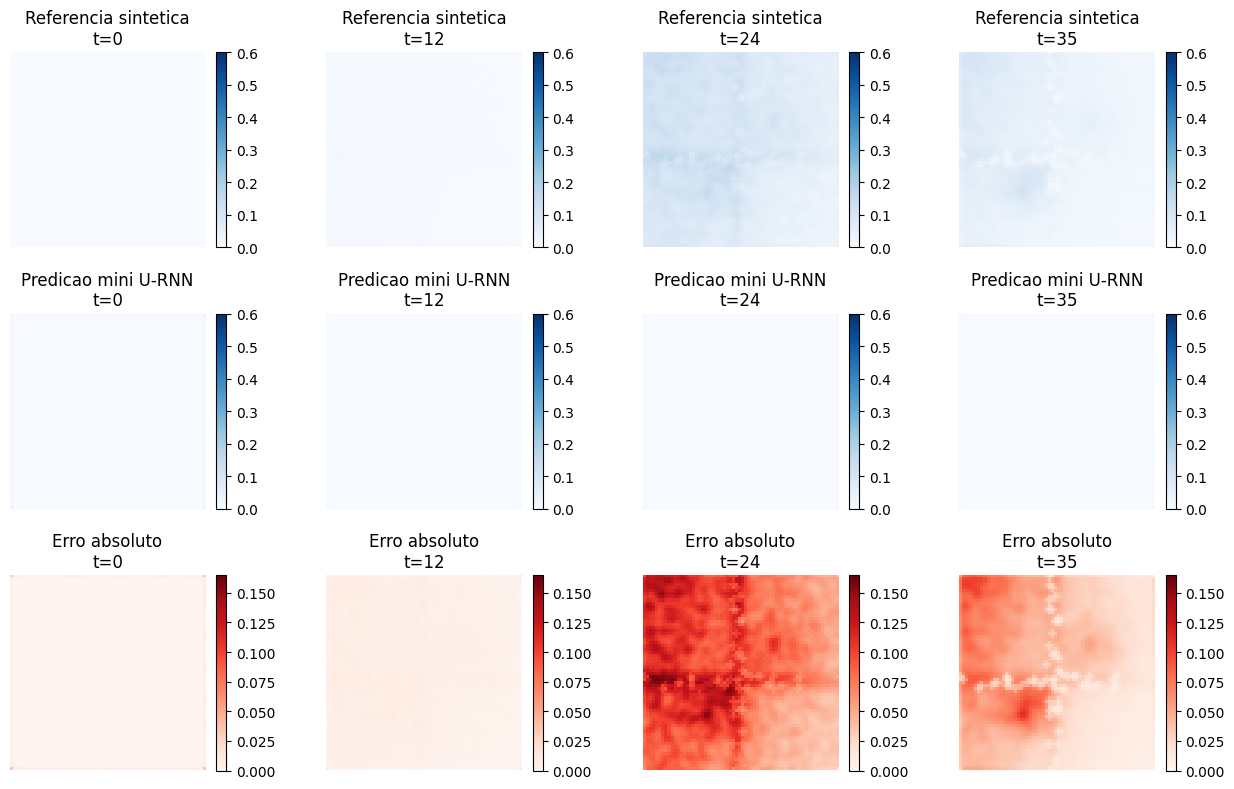

Figura salva: /content/U-RNN/code/outputs/figuras/comparacao_predicao_referencia.png


In [18]:
# Esta celula cria uma figura comparando referencia, predicao e erro absoluto.
# Ela imita a ideia de visualizacao do repositorio oficial: linhas para referencia,
# modelo e erro, com varios tempos da sequencia.

comparison_path = FIG_DIR / "comparacao_predicao_referencia.png"
time_points = [0, TIME_STEPS // 3, 2 * TIME_STEPS // 3, TIME_STEPS - 1]

fig, axes = plt.subplots(3, len(time_points), figsize=(13, 8))
rows = [
    ("Referencia sintetica", reference, "Blues", 0.0, MAX_DEPTH_M),
    ("Predicao mini U-RNN", prediction, "Blues", 0.0, MAX_DEPTH_M),
    ("Erro absoluto", absolute_error, "Reds", 0.0, max(0.12, float(absolute_error.max()))),
]

for row_index, (row_title, sequence, cmap, vmin, vmax) in enumerate(rows):
    for col_index, step in enumerate(time_points):
        axis = axes[row_index, col_index]
        image = axis.imshow(sequence[step], cmap=cmap, vmin=vmin, vmax=vmax)
        axis.set_title(f"{row_title}\nt={step}")
        axis.axis("off")
        fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(comparison_path, dpi=150)
plt.show()

print("Figura salva:", comparison_path)

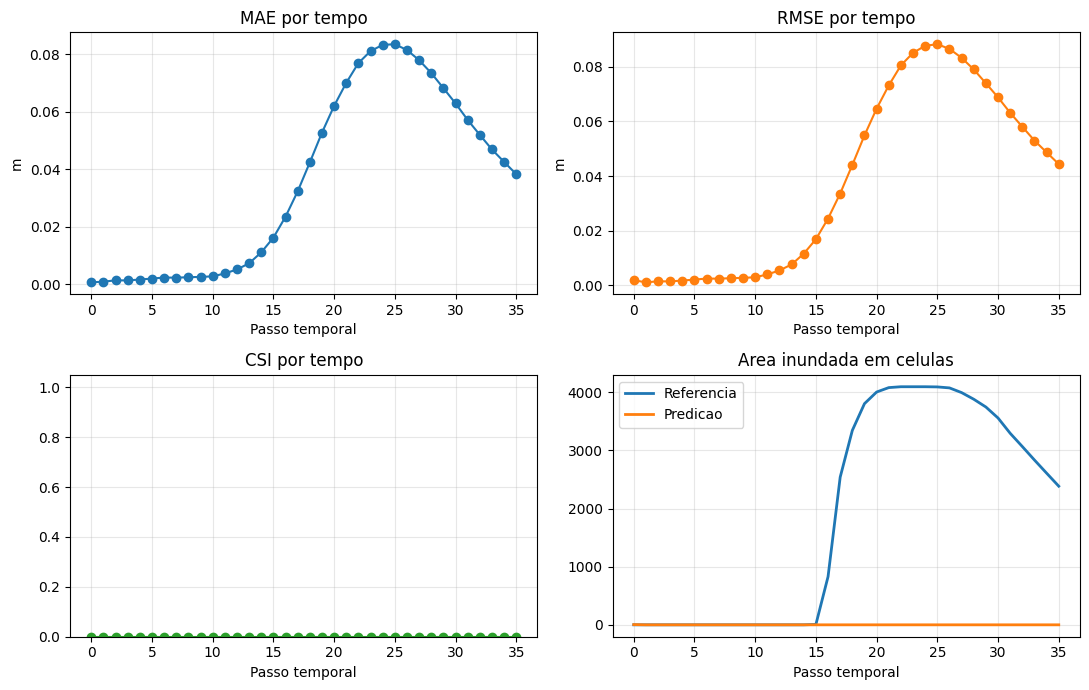

Figura salva: /content/U-RNN/code/outputs/figuras/metricas_temporais.png


In [19]:
# Esta celula plota as metricas ao longo do tempo.
# Isso ajuda a verificar se a qualidade muda durante a evolucao da chuva e da inundacao.

metrics_path = FIG_DIR / "metricas_temporais.png"
steps = np.arange(TIME_STEPS)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].plot(steps, metrics["mae"], marker="o")
axes[0, 0].set_title("MAE por tempo")
axes[0, 0].set_ylabel("m")

axes[0, 1].plot(steps, metrics["rmse"], marker="o", color="tab:orange")
axes[0, 1].set_title("RMSE por tempo")
axes[0, 1].set_ylabel("m")

axes[1, 0].plot(steps, metrics["csi"], marker="o", color="tab:green")
axes[1, 0].set_title("CSI por tempo")
axes[1, 0].set_ylim(0, 1.05)

axes[1, 1].plot(steps, metrics["ref_area"], label="Referencia", linewidth=2)
axes[1, 1].plot(steps, metrics["pred_area"], label="Predicao", linewidth=2)
axes[1, 1].set_title("Area inundada em celulas")
axes[1, 1].legend()

for axis in axes.ravel():
    axis.set_xlabel("Passo temporal")
    axis.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(metrics_path, dpi=150)
plt.show()

print("Figura salva:", metrics_path)

In [20]:
# Esta celula cria um GIF da profundidade prevista ao longo do tempo.
# O GIF e uma evidencia visual direta de nowcasting, pois mostra a evolucao temporal.

gif_path = GIF_DIR / "nowcasting.gif"

def depth_to_rgb_frame(depth, max_depth, scale=8):
    """Converte uma matriz de profundidade em imagem RGB usando colormap."""
    normalized = np.clip(depth / max_depth, 0.0, 1.0)
    rgba = plt.cm.Blues(normalized)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    image = Image.fromarray(rgb)
    return image.resize((depth.shape[1] * scale, depth.shape[0] * scale), Image.Resampling.NEAREST)


frames = [depth_to_rgb_frame(prediction[step], MAX_DEPTH_M) for step in range(TIME_STEPS)]
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=180,
    loop=0,
)

print("GIF salvo:", gif_path)

GIF salvo: /content/U-RNN/code/outputs/animacoes/nowcasting.gif


## Registro das evidências

Além de mostrar os gráficos no notebook, esta etapa salva os resultados em arquivos. Isso é importante para a entrega da atividade, porque permite verificar o funcionamento sem depender apenas da visualização das células executadas.

Os arquivos gerados ficam em `outputs/figuras`, `outputs/animacoes`, `outputs/metricas` e `outputs/logs`.


In [21]:
# Esta celula salva metricas e log de execucao em arquivos.
# Esses arquivos ajudam na auditoria da entrega pelo avaliador.

metrics_csv_path = METRIC_DIR / "metricas.csv"
history_csv_path = METRIC_DIR / "historico_treinamento.csv"
summary_json_path = LOG_DIR / "resumo_execucao.json"

with metrics_csv_path.open("w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["time_step", "mae_m", "rmse_m", "csi", "ref_area_cells", "pred_area_cells"])
    for step in range(TIME_STEPS):
        writer.writerow([
            step,
            float(metrics["mae"][step]),
            float(metrics["rmse"][step]),
            float(metrics["csi"][step]),
            int(metrics["ref_area"][step]),
            int(metrics["pred_area"][step]),
        ])

with history_csv_path.open("w", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=["epoch", "train_loss", "val_mse"])
    writer.writeheader()
    writer.writerows(history)

execution_summary = {
    "device": str(DEVICE),
    "grid": [GRID_H, GRID_W],
    "time_steps": TIME_STEPS,
    "train_events": TRAIN_EVENTS,
    "test_events": TEST_EVENTS,
    "epochs": EPOCHS,
    "summary_metrics": summary,
    "outputs": {
        "rainfall": str(rain_path),
        "spatial_fields": str(spatial_path),
        "comparison": str(comparison_path),
        "temporal_metrics": str(metrics_path),
        "gif": str(gif_path),
        "metrics_csv": str(metrics_csv_path),
        "training_history_csv": str(history_csv_path),
    },
}

with summary_json_path.open("w") as file:
    json.dump(execution_summary, file, indent=2)

print("Metricas salvas:", metrics_csv_path)
print("Historico salvo:", history_csv_path)
print("Resumo salvo:", summary_json_path)

Metricas salvas: /content/U-RNN/code/outputs/metricas/metricas.csv
Historico salvo: /content/U-RNN/code/outputs/metricas/historico_treinamento.csv
Resumo salvo: /content/U-RNN/code/outputs/logs/resumo_execucao.json


## Observação sobre a rota oficial

A inferência oficial com UrbanFlood24 Lite e pesos pré-treinados já foi movida para o início deste notebook e deve ser executada como rota principal.

As próximas células mantêm a implementação sintética didática, que serve para explicar os conceitos de forma controlada.


In [22]:
# Esta célula foi mantida apenas para indicar que a rota oficial já foi executada acima.
print("A inferência oficial com UrbanFlood24 Lite está nas primeiras seções deste notebook.")


A inferência oficial com UrbanFlood24 Lite está nas primeiras seções deste notebook.


## Interpretação dos resultados e limitações

Este notebook possui duas camadas de resultado.

A primeira, e mais importante para a entrega, é a **inferência oficial do U-RNN** com UrbanFlood24 Lite e pesos pré-treinados. Essa etapa usa `test.py`, `configs/lite.yaml`, checkpoint oficial e um evento demonstrativo com referência hidrodinâmica. A figura gerada pelo repositório oficial mostra referência MIKE+, predição U-RNN e erro absoluto.

A segunda camada é a **mini U-RNN sintética**, mantida para fins didáticos. Ela demonstra como entradas de chuva, camadas espaciais, estado recorrente, inferência autoregressiva e métricas podem ser organizados em um pipeline menor.

Limitações técnicas:

- a inferência oficial usa apenas um evento demonstrativo do UrbanFlood24 Lite, não o dataset completo;
- UrbanFlood24 Lite é uma versão reduzida do UrbanFlood24, com grade `128 x 128` e `36` passos temporais;
- a seção sintética não substitui a validação oficial;
- o notebook executa inferência com pesos prontos, mas não treina o U-RNN oficial do zero;
- o resultado não deve ser apresentado como avaliação completa de risco, pois risco exige exposição, vulnerabilidade, população, infraestrutura crítica e impactos potenciais.

Aplicação ao Americas TechGuard:

A inferência oficial mostra como um modelo U-RNN treinado pode gerar mapas temporais de inundação a partir de chuva, terreno e dados urbanos. Em uma prova de conceito real do Americas TechGuard, seria necessário substituir o evento demonstrativo por dados locais, validar com eventos históricos, integrar sensores ou previsão de chuva e conectar os resultados a dashboards e fluxos de alerta.
